# Named Entity Recognition and Classification
## Install/import libraries

In [14]:
from collections import Counter 
import pandas as pd
from sklearn.metrics import classification_report
from sklearn import svm
import gensim
import csv
from nltk.corpus.reader import ConllCorpusReader

## Data exploration

In [15]:
# Load the IPM NEL dataset
path_to_train_folder = "training_sets/"
conll_path = f"{path_to_train_folder}ipm_nel_corpus/"
conll_train = ConllCorpusReader(conll_path, 'ipm_nel.conll', ['words', 'ignore', 'ne', 'pos'])

In [ ]:
# the regular conell file was giving me so much trouble due to inconsistent value with
# tab and I kept getting value error even when i tried to work w the tabs
# so I changed it to a csv so it would be easier to work with is that ok i am sorry lol

def conll_to_csv(conll_file, csv_file):
    with open(conll_file, 'r', encoding='utf-8') as conll, open(csv_file, 'w', newline='', encoding='utf-8') as csvf:
        conll_lines = conll.read().strip().split('\n')
        writer = csv.writer(csvf)
        writer.writerow(['token', 'DBpedia_URL', 'NER_Tag', 'POS_Tag'])  # headers corresponding to the original conell

        for line in conll_lines:
            columns = line.split('\t')
            
            # filling missing values with 'null'
            while len(columns) < 4:
                columns.append('null')
            
            # token, DBpedia URL, NER tag, and POS tag (or 'null' if missing)
            writer.writerow(columns[:4])

conll_file = "training_sets/ipm_nel_corpus/ipm_nel.conll"
#conll_file = "training_sets/ipm_nel_corpus/ritter-ne-eval.conll"
#conll_file = "training_sets/ipm_nel_corpus/ritter-ne-train.conll"
csv_file = 'output_file.csv' 
conll_to_csv(conll_file, csv_file)


In [ ]:
import re
import os 
import html

# no need to run this because the tsv was already made

input = "training_sets/ipm_nel_corpus/ipm_nel.csv"
input2 = "training_sets/ipm_nel_corpus/ritter_ne_train.csv"
input3 = "training_sets/ipm_nel_corpus/ritter_ne_eval.csv"

output = "training_sets/ipm_nel_corpus/NERC_preprocessed.tsv"
output2 = "training_sets/ipm_nel_corpus/conll_combined_train.tsv"

# adding this in case I want to add additional cleaning later
def clean_token(text):
    
    emoticons = {":)", ":(", ";)", ":D", "=(", "=)", ":-)", ":-(", ":-D", ":-/", ":o", ":O"}
    
    # change the html entity to corresponding representation
    text = html.unescape(text)
    
    # removing links
    text = re.sub(r'http[s]?://\S+', '', text) 
    
    # removing parentheses to make sentence start and stop simpler. 
    if text not in emoticons and ("(" in text or ")" in text):
        text = re.sub(r'[()]', "", text)

    # make sure each token doesn't have additional trailing white space
    return text.strip()

def is_sentence_ender(token):
    
    # only listed the ones I found in the ipm_nel set + the other sets 
    emoticons = {":)", ":(", ";)", ":D", "=(", "=)", ":-)", ":-(", ":-D", ":-/", ":o", ":O", ":/"}
    
    # punctuation set
    punc_set = ".?!"
    
    if any(char in punc_set for char in token) or token in emoticons:
        return (True)
    return (False)

# just for the ipm_nel one
def add_to_tsv(*inputs, output):

    data = []
    sentence_id = 0
    
    for input in inputs:
        
        with open(input, "r", encoding="utf-8") as infile:
            reader = csv.DictReader(infile)
            
            for row in reader:
                
                token = row['token']
                ner_tag = row['NER_Tag']
                
                token = clean_token(token)
                
                if not token:
                    continue
                
                # capitalizing to match w the test labels + removing white space just in case
                ner_tag = ner_tag.upper()
                ner_tag = re.sub(r'\s+', '', ner_tag)

                data.append([sentence_id, token, ner_tag])
                
                if is_sentence_ender(token):
                    sentence_id += 1

            df = pd.DataFrame(data, columns=["sentence_id", "token", "BIO_NER_tag"])
            df.to_csv(output, sep="\t", index=True, index_label='token_id', mode="a", header=True)
    
add_to_tsv(input, input2, input3, output=output2)

#NERC_preprocessed.tsv is the one with ipm_nel preprocessed by itself without the other files
#conll_combined has all the conll that were uploaded all together. I wasn't 100% sure if we wanted all or just the one
# if we want just the one take out the input for inputs and change where the df =s are indented (outside with open)


In [60]:
#input = pd.read_csv(
#    "training_sets/ipm_nel_corpus/NERC_preprocessed.tsv",
#    sep="\t",
#    usecols=["token_id", "sentence_id", "token", "BIO_NER_tag"]
#    )

input2 = pd.read_csv(
    "training_sets/ipm_nel_corpus/conll_combined_train.tsv",
    sep="\t",
    usecols=["token_id", "sentence_id", "token", "BIO_NER_tag"]
    )

print(input2.isnull().value_counts())

token_id  sentence_id  token  BIO_NER_tag
False     False        False  False          93364
Name: count, dtype: int64


In [61]:
# counting frequency of the NER tags that show up in the training and test data

training_ner = pd.read_csv("training_sets/ipm_nel_corpus/conll_combined_train.tsv", sep="\t", header=None, skiprows=1)
testing_ner = pd.read_csv("test_sets/NER-test.tsv", sep="\t", on_bad_lines='skip', header=None, skiprows=1)

training_ner.columns = ['token_id', 'sentence_id', 'token', 'BIO_NER_tag']
testing_ner.columns = ['token_id', 'sentence_id', 'token', 'BIO_NER_tag']

ner_labels_train = training_ner['BIO_NER_tag']
ner_labels_test = testing_ner['BIO_NER_tag']

ner_labels_train_counts = Counter(ner_labels_train)
ner_labels_test_counts = Counter(ner_labels_test)

ner_train_dict = dict(ner_labels_train_counts)
ner_test_dict = dict(ner_labels_test_counts)

print("TRAINING NER TAG:", ner_train_dict)
print("TEST NER TAG:", ner_test_dict)

# key: NER tag
# value: NER tag frequency count


TRAINING NER TAG: {'B-SPORTSTEAM': 48, 'O': 87413, 'B-PERSON': 216, 'B-GEO-LOC': 201, 'B-FACILITY': 42, 'I-FACILITY': 48, 'I-PERSON': 150, 'I-SPORTSTEAM': 30, 'I-GEO-LOC': 42, 'B-MOVIE': 21, 'B-MUSICARTIST': 39, 'B-TVSHOW': 27, 'I-TVSHOW': 15, 'B-OTHER': 108, 'I-OTHER': 153, 'B-COMPANY': 93, 'I-MUSICARTIST': 48, 'I-MOVIE': 24, 'B-PRODUCT': 81, 'I-PRODUCT': 84, 'I-COMPANY': 18, 'BIO_NER_tag': 2, 'ORGANIZATION': 510, 'PERSON': 1184, 'LOCATION': 959, 'MISC': 1808}
TEST NER TAG: {'O': 185, 'B-ORG': 3, 'I-ORG': 2, 'B-PERSON': 11, 'B-LOC': 7, 'I-PERSON': 8, 'B-WORK_OF_ART': 9, 'I-WORK_OF_ART': 10, 'I-LOC': 1}


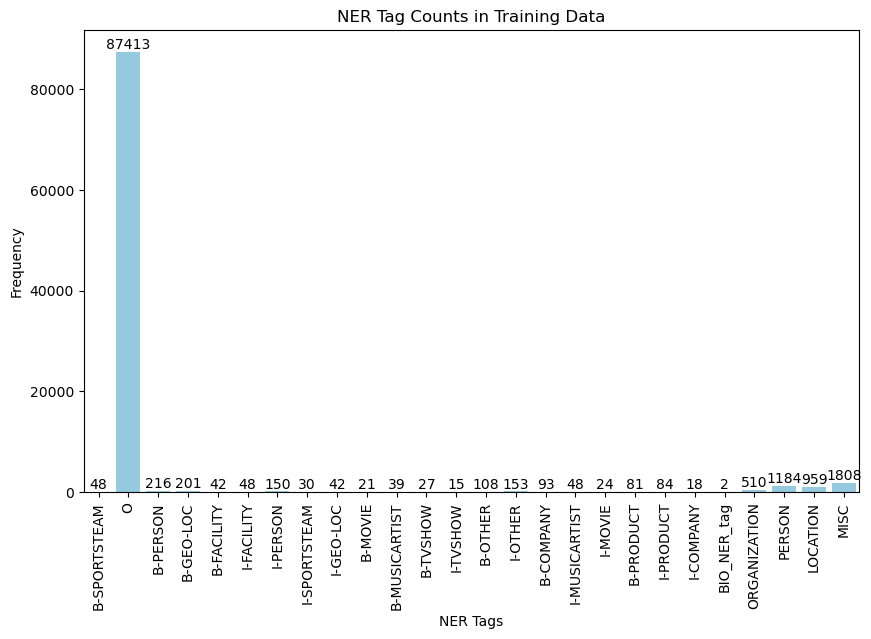

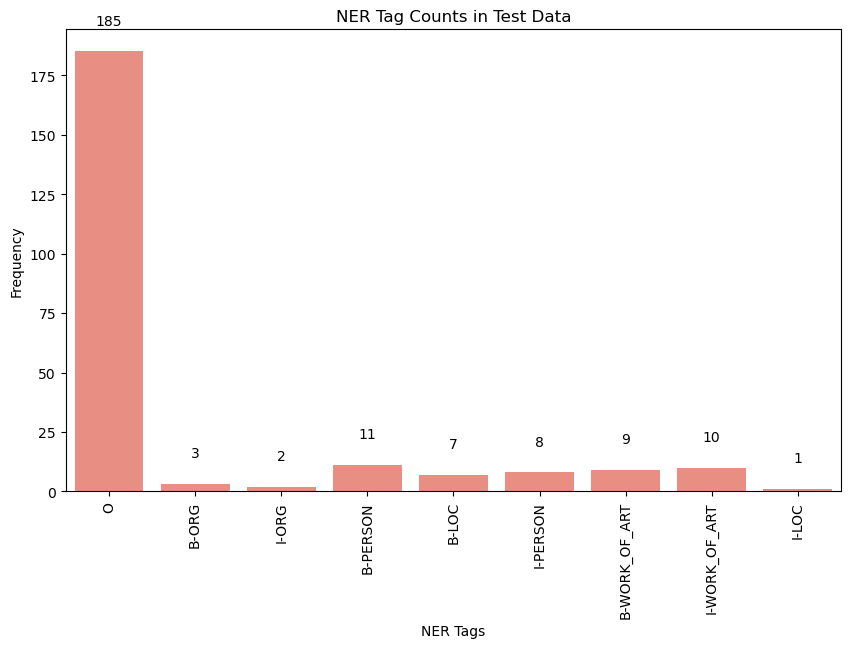

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns

# can delete if unnecessary just wanted to add a visual for perspective if it was helpful

plt.figure(figsize=(10, 6))
sns.barplot(x=list(ner_train_dict.keys()), y=list(ner_train_dict.values()), color='skyblue')
plt.title("NER Tag Counts in Training Data")
plt.xlabel("NER Tags")
plt.ylabel("Frequency")
plt.xticks(rotation=90)

for i, value in enumerate(ner_train_dict.values()):
    plt.text(i, value + 10, str(value), ha='center', va='bottom', fontsize=10)
    
plt.show()

plt.figure(figsize=(10, 6))
sns.barplot(x=list(ner_test_dict.keys()), y=list(ner_test_dict.values()), color='salmon')
plt.title("NER Tag Counts in Test Data")
plt.xlabel("NER Tags")
plt.ylabel("Frequency")
plt.xticks(rotation=90)

for i, value in enumerate(ner_test_dict.values()):
    plt.text(i, value + 10, str(value), ha='center', va='bottom', fontsize=10)
    
plt.show()

In [63]:
import matplotlib.pyplot as plt
from matplotlib_venn import venn2

train_labels_set = set(ner_train_dict.keys())
test_labels_set = set(ner_test_dict.keys())

shared_labels = train_labels_set.intersection(test_labels_set)
unique_train_labels = train_labels_set - test_labels_set
unique_test_labels = test_labels_set - train_labels_set

print(f"Shared Labels: {shared_labels}")
print(f"Unique Labels in Training Set: {unique_train_labels}")
print(f"Unique Labels in Test Set: {unique_test_labels}")


Shared Labels: {'B-PERSON', 'O', 'I-PERSON'}
Unique Labels in Training Set: {'B-OTHER', 'B-TVSHOW', 'B-COMPANY', 'B-GEO-LOC', 'I-PRODUCT', 'B-MUSICARTIST', 'I-COMPANY', 'I-TVSHOW', 'I-MUSICARTIST', 'PERSON', 'B-FACILITY', 'B-MOVIE', 'BIO_NER_tag', 'I-SPORTSTEAM', 'I-GEO-LOC', 'B-PRODUCT', 'ORGANIZATION', 'MISC', 'B-SPORTSTEAM', 'I-FACILITY', 'I-MOVIE', 'I-OTHER', 'LOCATION'}
Unique Labels in Test Set: {'I-ORG', 'I-LOC', 'B-LOC', 'B-WORK_OF_ART', 'B-ORG', 'I-WORK_OF_ART'}


## Create features

We create the features for the training and test datasets.

In [ ]:
training_features = []
training_gold_labels = []

"""
for token, pos, ne_label in conll_train.iob_words():
    training_feature = {
       'token': token,
       'pos': pos
    }


    training_features.append(training_feature)
    training_gold_labels.append(ne_label)
"""

"\nfor token, pos, ne_label in conll_train.iob_words():\n    training_feature = {\n       'token': token,\n       'pos': pos\n    }\n\n    training_features.append(training_feature)\n    training_gold_labels.append(ne_label)\n"

In [7]:
test_features = []
test_gold_labels = []

"""
for token, pos, ne_label in ...:
    test_feature = {
       'token': token,
       'pos': pos
    }

    test_features.append(test_feature)
    test_gold_labels.append(ne_label)
"""

"\nfor token, pos, ne_label in ...:\n    test_feature = {\n       'token': token,\n       'pos': pos\n    }\n\n    test_features.append(test_feature)\n    test_gold_labels.append(ne_label)\n"

## Descriptive statistics
Frequency distribution of the NERC labels in the training and test data:

In [8]:
train_label_counts = Counter(training_gold_labels)
test_label_counts = Counter(test_gold_labels)

print("NERC label frequency in training data:")
for label, count in train_label_counts.most_common():
    print(f"{label}: {count}")

print("\nNERC label frequency in test data:")
for label, count in test_label_counts.most_common():
    print(f"{label}: {count}")

NERC label frequency in training data:

NERC label frequency in test data:


Analyzing training and test data (im)balance:

In [9]:
train_total = sum(train_label_counts.values())
test_total = sum(test_label_counts.values())

print("\nPercentage distribution in training data:")
for label, count in train_label_counts.most_common():
    percentage = (count / train_total) * 100
    print(f"{label}: {percentage}%")

print("\nPercentage distribution in test data:")
for label, count in test_label_counts.most_common():
    percentage = (count / test_total) * 100
    print(f"{label}: {percentage}%")


Percentage distribution in training data:

Percentage distribution in test data:


#TODO: explain distribution

## Vectorize data
For more balanced performance across entity types and shorter model training time, we use Google's pre-trained Word2Vec word embedding model to obtain vectors for our training and test features.

In [10]:
# Load word embedding model
gensim_path = 'GoogleNews-vectors-negative300.bin\\GoogleNews-vectors-negative300.bin'
word_embedding_model = gensim.models.KeyedVectors.load_word2vec_format(gensim_path, binary=True)

# Initialize arrays
training_vec = []
test_vec = []

# Obtain vectors for training features
for token_dict in training_features:
    word = token_dict['token']

    # Is word in the model vocabulary (loaded with the Google word2vec embeddings)?
    if word in word_embedding_model:
        vector = word_embedding_model[word]  # assign embedding vector value to variable
    else: 
        vector = [0] * 300  # Create a vector with 300 zeros, as word2vec model has 300 dimensions

    training_vec.append(vector)

# Obtain vectors for test features
for token_dict in test_features:
    word = token_dict['token']

    # Is word in the model vocabulary (loaded with the Google word2vec embeddings)?
    if word in word_embedding_model:
        vector = word_embedding_model[word]  # assign embedding vector value to variable
    else: 
        vector = [0] * 300  # Create a vector with 300 zeros as word2vec model has 300 dimensions

    test_vec.append(vector)

FileNotFoundError: [Errno 2] No such file or directory: 'GoogleNews-vectors-negative300.bin\\GoogleNews-vectors-negative300.bin'

## Training the Support Vector Machine
Since the training data contains a varying amount of instances across domains, there is a need for a model that is robust against overfitting. SVMs provide robustness via the use of a regularization parameter, often denoted as `C`. Furthermore, SVMs are based on the maximization of margins between classes. This often leads to good generalization performance, which is crucial for our task of minimizing misclassifications (especially across similar entity types). 

We choose the linear kernel, as the linear kernel of SVMs may outperform the polynomial and RBF kernel for the NER task (Alokaili and Menai, 2019).

In [ ]:
lin_clf = svm.LinearSVC(kernel='linear')

# NOTE: DON'T run this cell again if you've already trained the SVM! It may take up to 10 minutes!
lin_clf.fit(training_vec, training_gold_labels)

## Make predictions for the test set and evaluate
Make predictions with the model (predict the NER labels of the tokens in the test set).

In [ ]:
# Obtain predictions from the SVM model
svm_predictions = lin_clf.predict(test_vec)

# Generate the classification report and print it
class_report = classification_report(test_gold_labels, svm_predictions)
print(class_report)

#TODO: Analyze classification report

* Which NERC labels does the classifier perform well on? Why do you think this is the case?
* Which NERC labels does the classifier perform poorly on? Why do you think this is the case?
